# Schedl-Style Feedback-Loop Audit
## Country, language and popularity calibration in movie recommendations

This notebook extends the cultural prominence audit with the feedback-loop logic from Lesota, Geiger, Walder, Kowald and Schedl (2024), *Oh, Behave! Country Representation Dynamics Created by Feedback Loops in Music Recommender Systems*.

The original paper studies local and US-produced music. Our MovieLens/M3L setting has no user-country field, so we adapt the logic carefully: **local** becomes the user's observed cultural profile in their initial movie history. A recommender is culturally miscalibrated when its Top-K country/language/popularity distribution drifts away from that profile.

## What the feedback loop does

1. Train a recommender on the current user profiles.
2. Recommend Top-10 unseen movies per user.
3. Simulate one accepted item per user with rank-biased acceptance probability.
4. Add the accepted item to the user profile.
5. Retrain and repeat.

This is not a replacement for the Top-K audit. It adds the missing dynamic question from the Schedl paper: **does repeated recommendation push user profiles toward or away from European, non-English and non-US content over time?**

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUTPUTS = PROJECT_ROOT / "outputs"

run_report = pd.read_csv(OUTPUTS / "31_feedback_loop_run_report.csv")
model_ledger = pd.read_csv(OUTPUTS / "31_schedl_model_ledger.csv")
final_summary = pd.read_csv(OUTPUTS / "31_feedback_loop_final_summary.csv")
iteration_metrics = pd.read_csv(OUTPUTS / "31_feedback_loop_iteration_metrics.csv")

display(run_report)
display(model_ledger)

,object,count
0,feedback-loop users,500.0
1,candidate items,5112.0
2,iterations,6.0
3,top-k recommendations,10.0
4,acceptance alpha,-0.1


,model,schedl_reference,local_implementation,status
0,Pop,Pop baseline,Most popular unseen item by current profile co...,executed
1,ItemKNN,ItemKNN,Cosine item-item collaborative filtering,executed
2,BPR-MF,BPR,PyTorch Bayesian Personalized Ranking matrix f...,executed
3,LightGCN-style,LightGCN,One-step normalized user-item graph propagatio...,executed as transparent lightweight approximation
4,NeuMF-lite,NeuMF,PyTorch neural matrix-factorisation-style pair...,executed as lightweight local variant
5,MultiVAE-lite,MultiVAE,PyTorch variational autoencoder over user-item...,executed as lightweight local variant


In [2]:
# Focus the table on the cultural shifts that map directly to the project question.
view_cols = [
    "Model",
    "initial_european_share",
    "recommendation_european_share",
    "recommendation_european_shift",
    "initial_non_english_share",
    "recommendation_non_english_share",
    "recommendation_non_english_shift",
    "initial_us_origin_share",
    "recommendation_us_origin_share",
    "recommendation_us_origin_shift",
    "recommendation_origin_jsd",
    "recommendation_language_jsd",
    "recommendation_popularity_jsd",
]
feedback_table = final_summary[view_cols].sort_values("recommendation_origin_jsd", ascending=False)
display(feedback_table.round(4))

strongest_europe_drop = feedback_table.loc[feedback_table["recommendation_european_shift"].idxmin()]
strongest_non_english_drop = feedback_table.loc[feedback_table["recommendation_non_english_shift"].idxmin()]
strongest_us_gain = feedback_table.loc[feedback_table["recommendation_us_origin_shift"].idxmax()]
highest_origin_jsd = feedback_table.loc[feedback_table["recommendation_origin_jsd"].idxmax()]
highest_popularity_jsd = feedback_table.loc[feedback_table["recommendation_popularity_jsd"].idxmax()]

interpretation = (
    f"**Feedback-loop interpretation.** After the simulated loop, **{strongest_europe_drop['Model']}** creates the largest European-origin drop "
    f"({strongest_europe_drop['recommendation_european_shift']:+.1%} against users' initial histories). "
    f"**{strongest_non_english_drop['Model']}** creates the largest non-English drop "
    f"({strongest_non_english_drop['recommendation_non_english_shift']:+.1%}). "
    f"The strongest US-origin gain appears for **{strongest_us_gain['Model']}** "
    f"({strongest_us_gain['recommendation_us_origin_shift']:+.1%}). "
    f"Country/origin miscalibration is highest for **{highest_origin_jsd['Model']}** "
    f"(JSD {highest_origin_jsd['recommendation_origin_jsd']:.3f}), while popularity miscalibration is highest for "
    f"**{highest_popularity_jsd['Model']}** (JSD {highest_popularity_jsd['recommendation_popularity_jsd']:.3f})."
)
display(Markdown(interpretation))

,Model,initial_european_share,recommendation_european_share,recommendation_european_shift,initial_non_english_share,recommendation_non_english_share,recommendation_non_english_shift,initial_us_origin_share,recommendation_us_origin_share,recommendation_us_origin_shift,recommendation_origin_jsd,recommendation_language_jsd,recommendation_popularity_jsd
0,BPR-MF,0.2208,0.1084,-0.1124,0.051,0.0124,-0.0386,0.902,0.9724,0.0704,0.0980,0.0588,0.0161
2,LightGCN-style,0.2208,0.1168,-0.1040,0.051,0.0168,-0.0342,0.902,0.9662,0.0642,0.0935,0.0506,0.0254
4,NeuMF-lite,0.2208,0.1250,-0.0958,0.051,0.0256,-0.0254,0.902,0.9736,0.0716,0.0902,0.0655,0.0193
3,MultiVAE-lite,0.2208,0.2680,0.0472,0.051,0.0586,0.0076,0.902,0.8624,-0.0396,0.0876,0.0504,0.1540
5,Pop,0.2208,0.1114,-0.1094,0.051,0.0002,-0.0508,0.902,0.9970,0.0950,0.0855,0.0501,0.0164
1,ItemKNN,0.2208,0.1734,-0.0474,0.051,0.0014,-0.0496,0.902,0.9604,0.0584,0.0788,0.0532,0.0183


**Feedback-loop interpretation.** After the simulated loop, **BPR-MF** creates the largest European-origin drop (-11.2% against users' initial histories). **Pop** creates the largest non-English drop (-5.1%). The strongest US-origin gain appears for **Pop** (+9.5%). Country/origin miscalibration is highest for **BPR-MF** (JSD 0.098), while popularity miscalibration is highest for **MultiVAE-lite** (JSD 0.154).

### European and non-English recommendation shares over feedback-loop iterations.

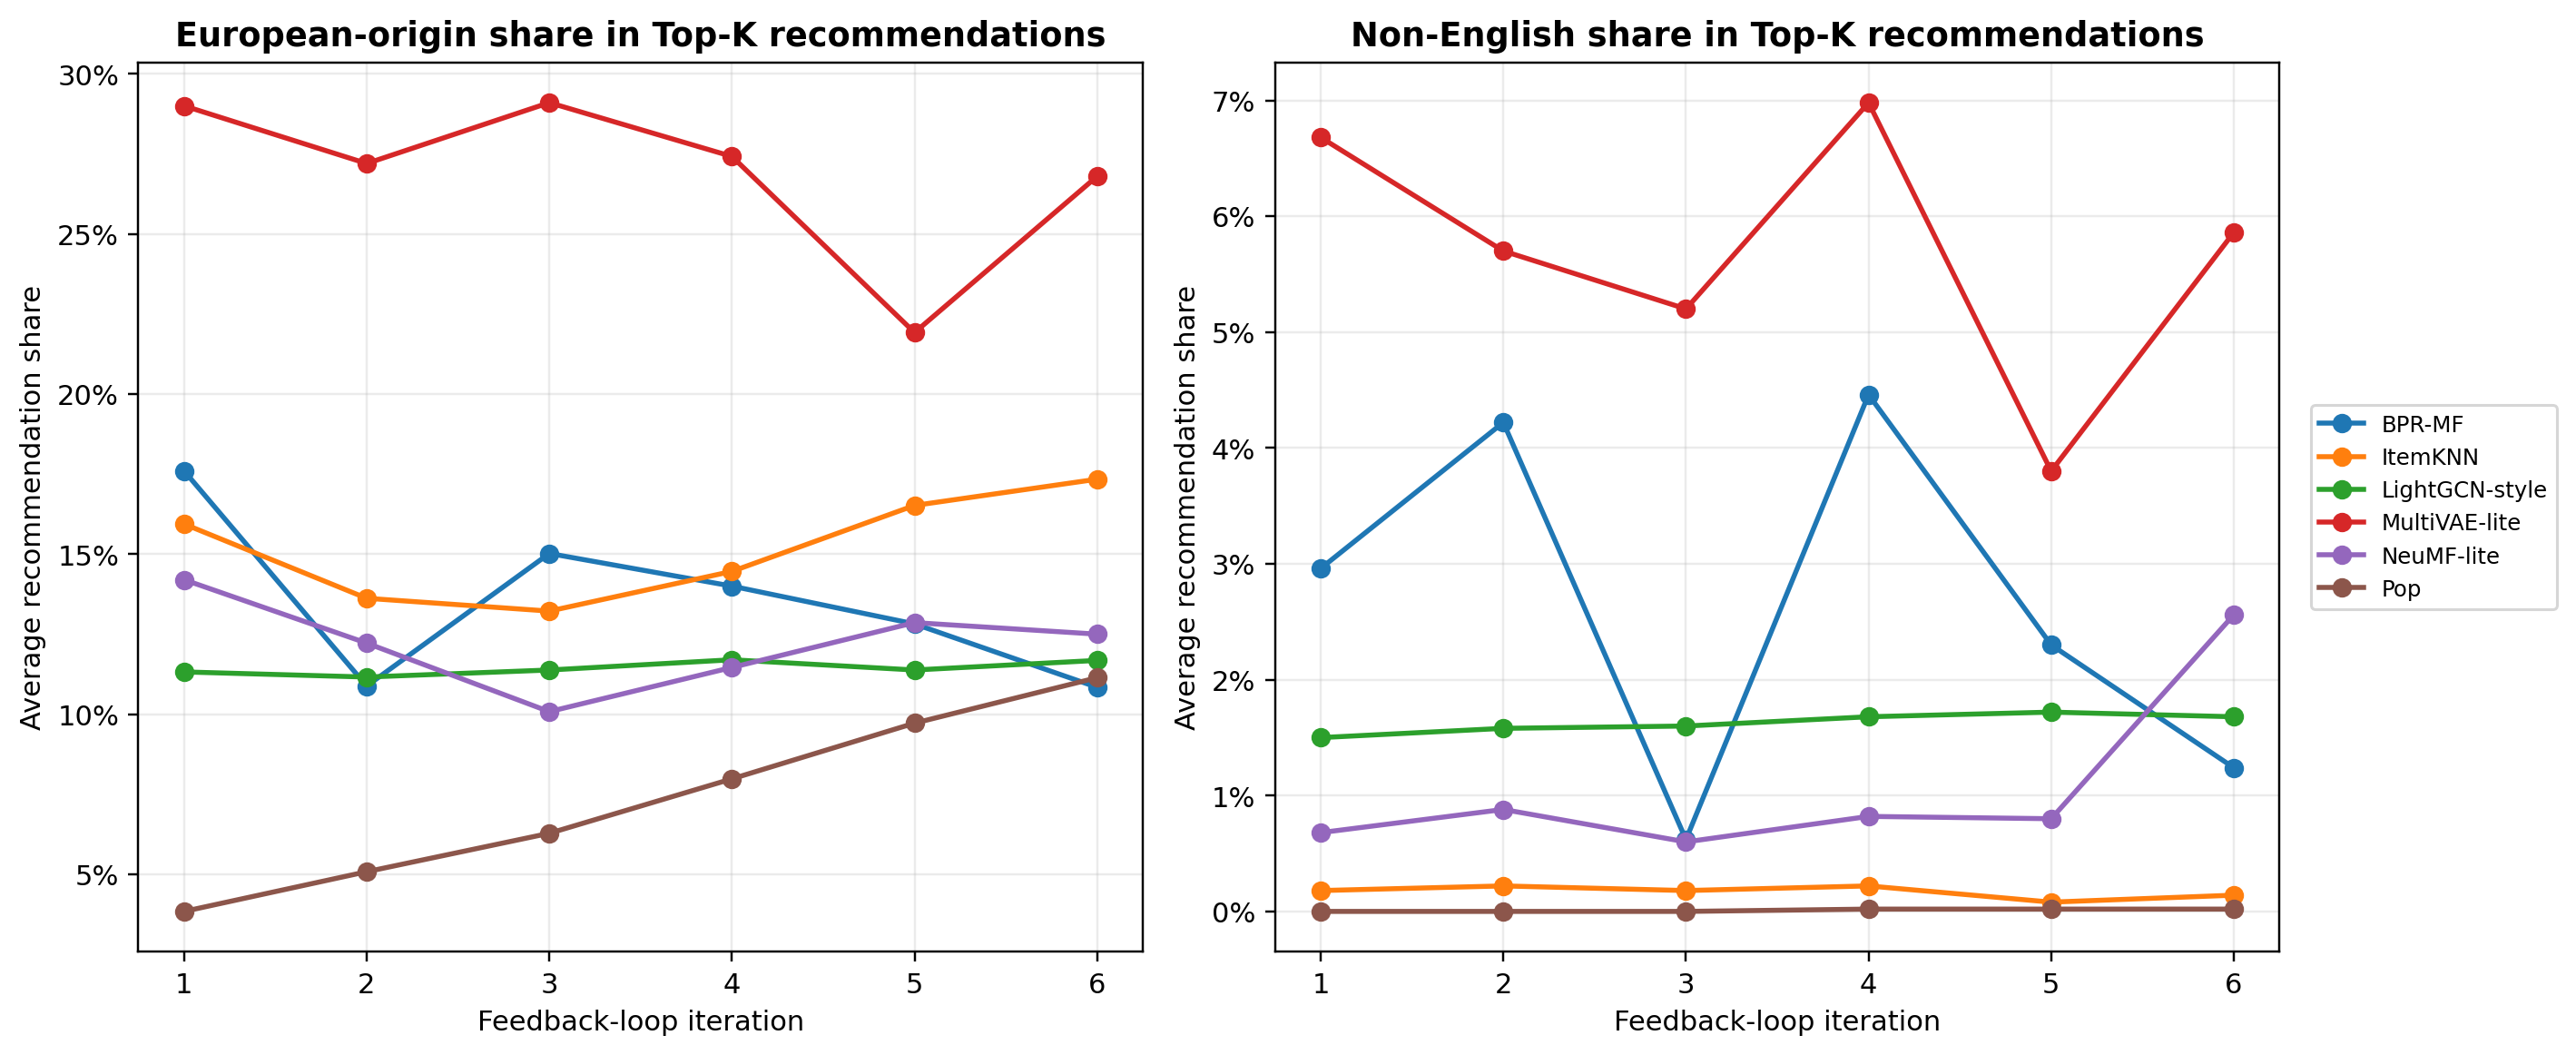

### Origin, language and popularity miscalibration after the simulation.

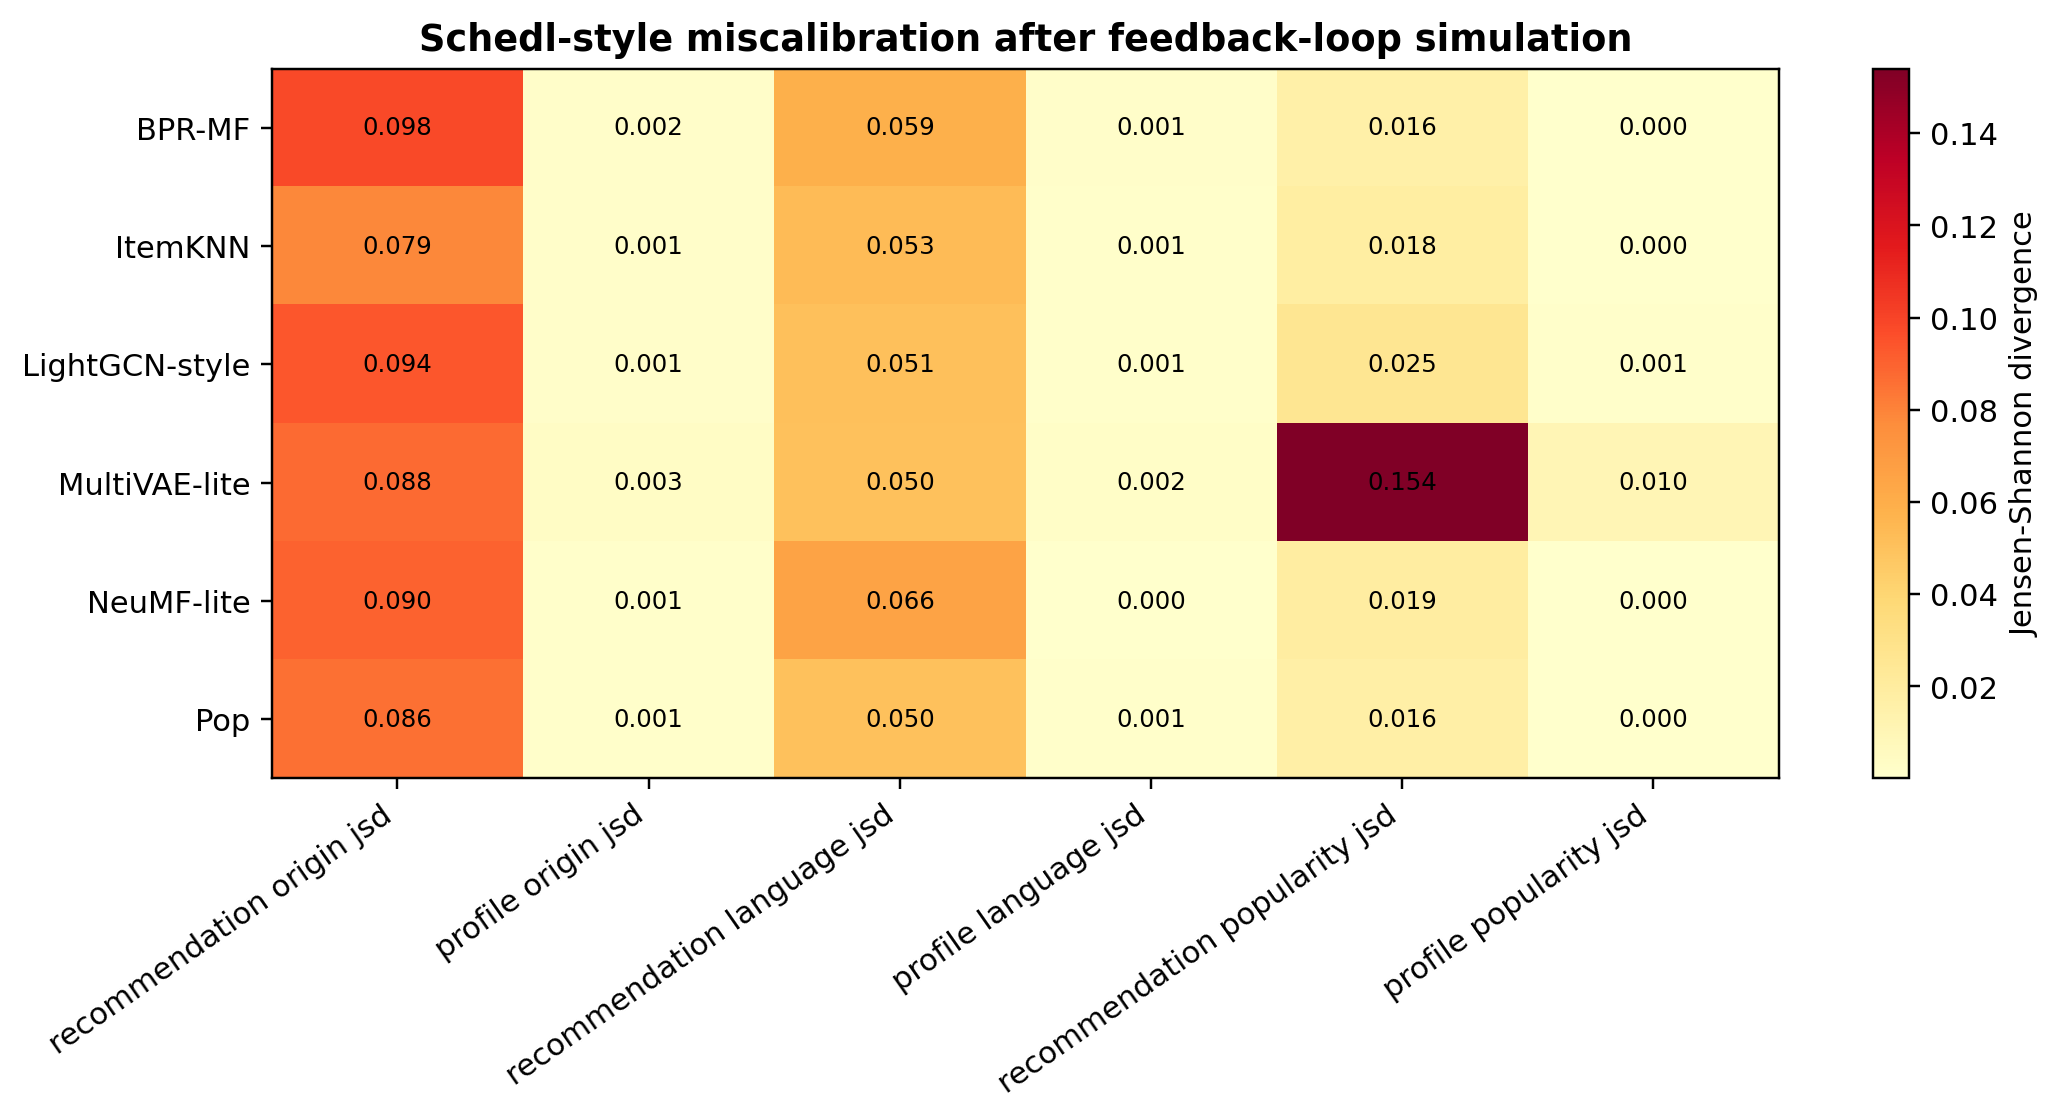

### Final Top-K composition shift relative to initial user histories.

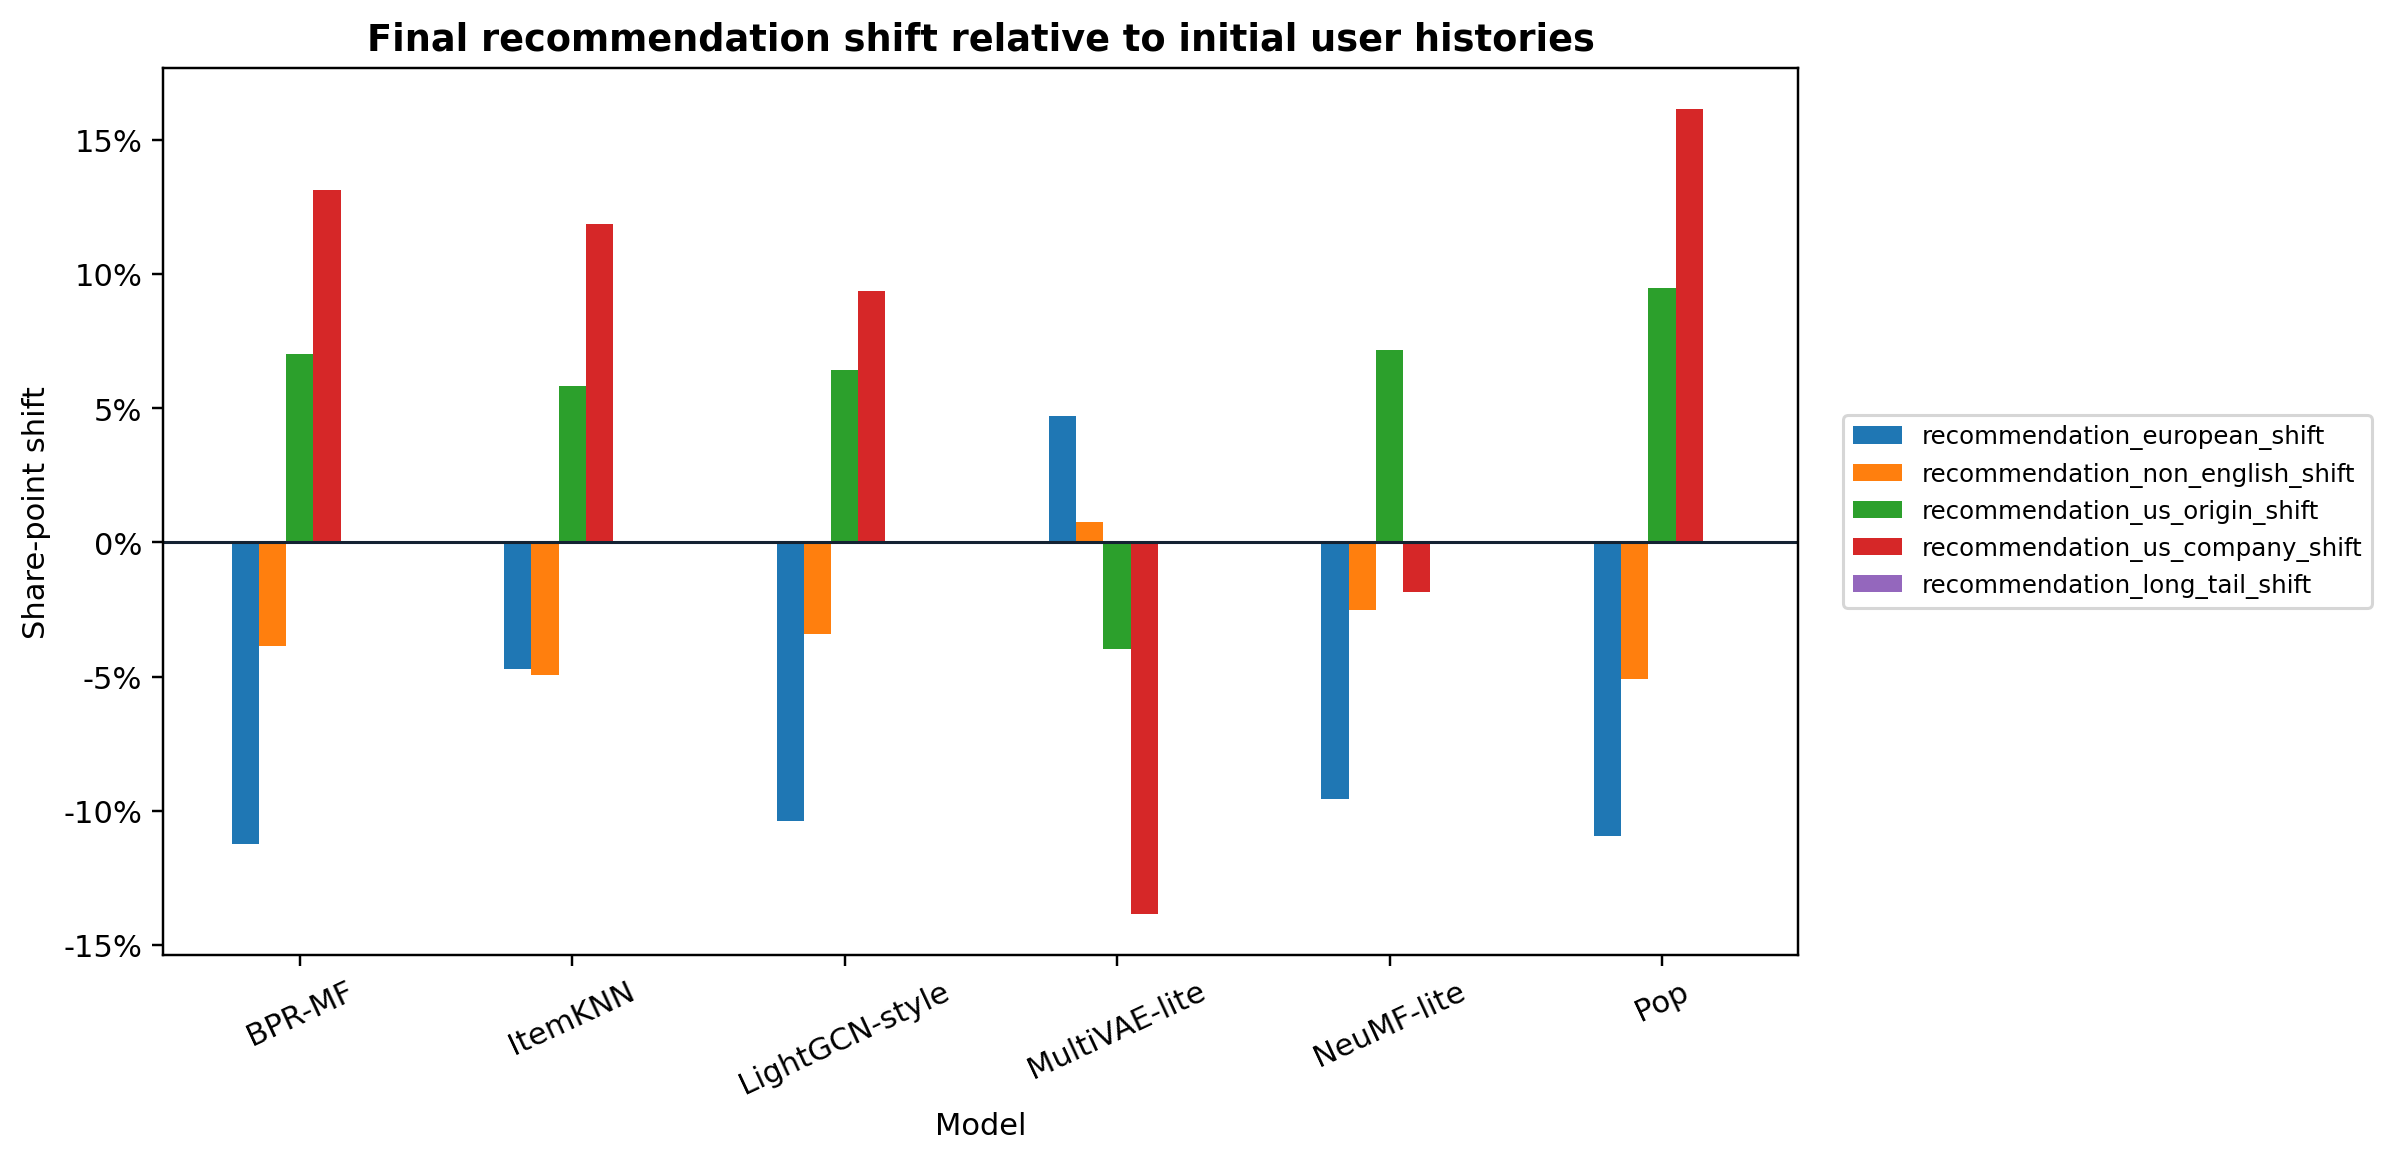

### Country and language bias panels for the final feedback-loop state.

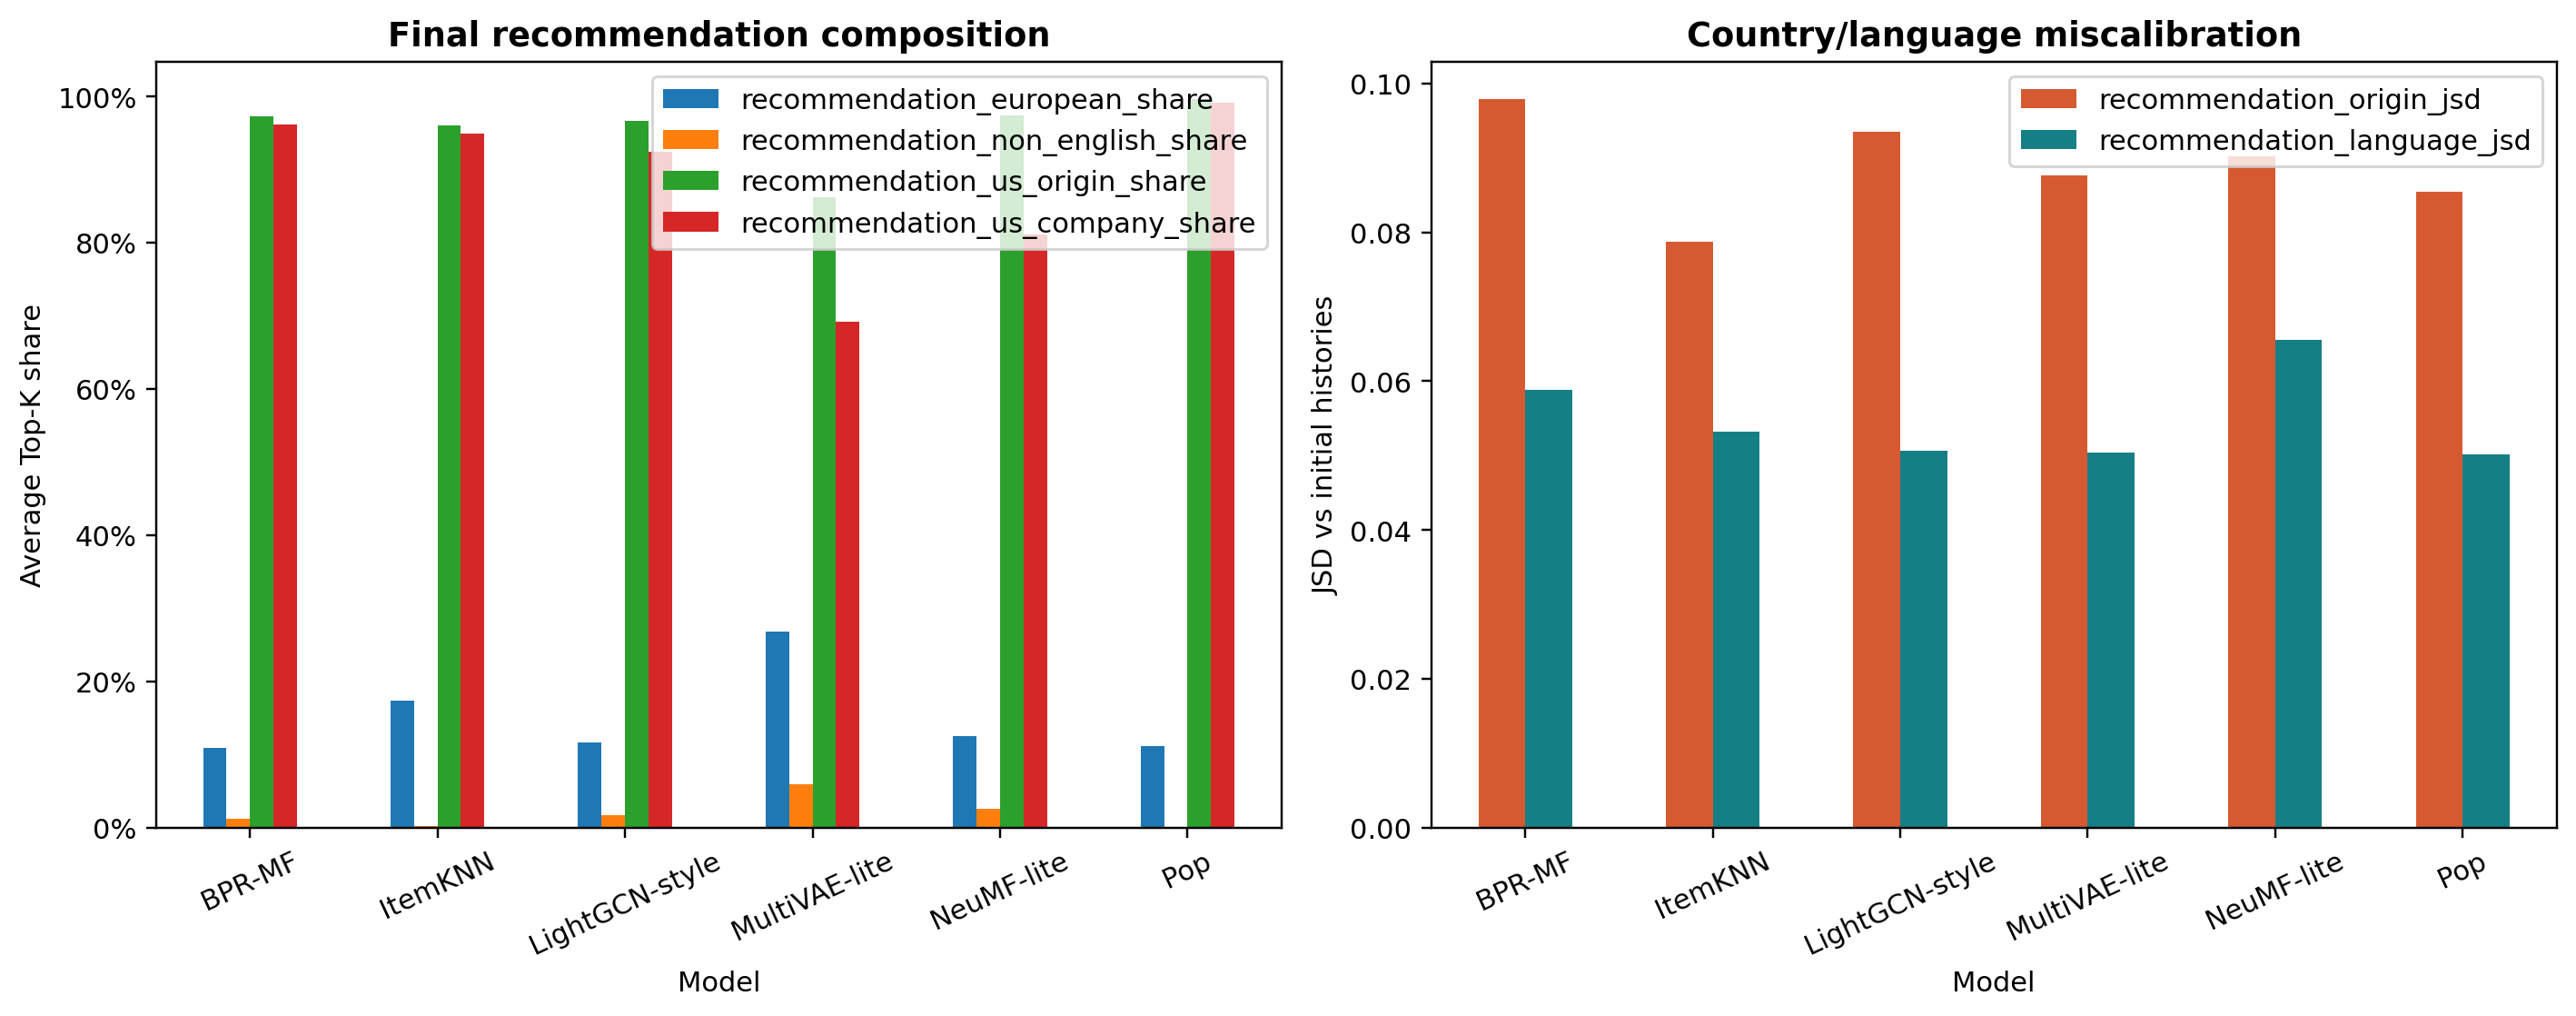

In [3]:
for filename, caption in [
    ("31_feedback_loop_representation_dynamics.png", "European and non-English recommendation shares over feedback-loop iterations."),
    ("32_feedback_loop_jsd_heatmap.png", "Origin, language and popularity miscalibration after the simulation."),
    ("33_feedback_loop_final_shift.png", "Final Top-K composition shift relative to initial user histories."),
    ("34_language_country_bias_panels.png", "Country and language bias panels for the final feedback-loop state."),
]:
    display(Markdown(f"### {caption}"))
    display(Image(filename=str(OUTPUTS / filename)))

## Interpretation caveats

- MovieLens/M3L does not contain user nationality. We therefore do **not** claim user-local country effects in the literal Schedl sense.
- We adapt the logic to user-history calibration: recommendation distributions are compared to each user's initial movie profile.
- LightGCN, NeuMF and MultiVAE are lightweight local variants, because the RecBole stack used in the paper is not installed in this workspace.
- The strict long-tail label is almost absent in the sampled feedback-loop histories. For this dynamic section, country/language/US-origin and popularity-bin JSD are more informative than the binary long-tail share.

## Next steps

1. Increase iterations from 6 toward 20-100 when runtime allows.
2. Run RecBole implementations of BPR, LightGCN, NeuMF and MultiVAE for exact comparability with Lesota et al. (2024).
3. Add a mitigation loop: apply the transparent re-ranker inside each iteration and compare drift against the unmitigated loop.
4. Report binary and fractional co-production counting side by side.

## References

- Lesota, O., Geiger, J., Walder, M., Kowald, D., & Schedl, M. (2024). *Oh, Behave! Country Representation Dynamics Created by Feedback Loops in Music Recommender Systems*. RecSys 2024 / arXiv:2408.11565.
- Mansoury et al. (2020). *Feedback Loop and Bias Amplification in Recommender Systems*.
- Steck (2018). *Calibrated Recommendations*.
- Wikidata properties P495, P364, P407 and P272 for country, language and production-company metadata.